In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2


### 1. Create a base mesh 

Use TempestRemap to generate a globally uniform mesh for the low resolution from which we add refinement for the RRM domain
In our example, we use ne32 as the base mesh

In [2]:
# Create an ne32 mesh for a base; use tempestremap for this
# ne32 is the base mesh for low resolution portion of RRM
from subprocess import run
import os
# os.makedirs('meshes', exist_ok=True)
res = 4
run(f'GenerateCSMesh --res {res} --file /tscratch/smturbe/e3sm_grids/ne{res}/ne{res}.g'.split(' '), capture_output=True)

CompletedProcess(args=['GenerateCSMesh', '--res', '4', '--file', '/tscratch/smturbe/e3sm_grids/ne4/ne4.g'], returncode=0, stdout=b'Parameters:\n  --res <integer> [4] \n  --file <string> ["/tscratch/smturbe/e3sm_grids/ne4/ne4.g"] \n  --out_format <string> ["Netcdf4"] \n  --alt <bool> [false] \n=========================================================\n..Generating mesh with resolution [4]\n..Writing mesh to file [/tscratch/smturbe/e3sm_grids/ne4/ne4.g] \nNodes per element\n..Block 1 (4 nodes): 96\n..Mesh generator exited successfully\n=========================================================\n', stderr=b'')

### 2. Create a refined mesh over the refinement area

The refinement area is provided by the .png image with a (black box on a white background to denote the area of refinement - this requires use to use the ```--invert``` option below)

In [ ]:
# Create a refined mesh with refinement area
refine_level=9  # refinement --> ne = 32 x 2^refine_level (in this example, ne = 32 x 512 = 16384 = 2^14)
run(f'../squadgen/SQuadGen --resolution {res} --refine_file meshes/CA_v1_input.png --refine_level {refine_level} --invert --smooth_type SPRING --output /tscratch/smturbe/e3sm_grids/CA_ne32_x256/CAne{res}_x{2**refine_level}_v1.g'.split(' '), capture_output=True)


CompletedProcess(args=['../squadgen/SQuadGen', '--resolution', '32', '--refine_file', 'meshes/CA_v1_input.png', '--refine_level', '9', '--invert', '--smooth_type', 'SPRING', '--output', '/tscratch/smturbe/e3sm_grids/CA_ne32_x256/CAne32_x512_v1.g'], returncode=0, stdout=b'Parameters:\n  --grid_type <string> ["CS"] (Options: CS | ICO | OCT1 | OCT2)\n  --refine_type <string> ["LOWCONN"] (Options: LOWCONN | CUBIT | LOWCONNOLD)\n  --refine_level <integer> [9] \n  --resolution <integer> [32] \n  --refine_file <string> ["meshes/CA_v1_input.png"] \n  --output <string> ["/tscratch/smturbe/e3sm_grids/CA_ne32_x256/CAne32_x512_v1.g"] \n  --loadcsrefinementmap <bool> [false] \n  --smooth_type <string> ["SPRING"] (Options: NONE | SPRING | PRESSURE)\n  --smooth_dist <integer> [1] (Smooth distance, -1 = smooth entire mesh)\n  --smooth_iter <integer> [10] \n  --lon_base <double> [-180.000000] \n  --lat_base <double> [0.000000] \n  --x_rotate <double> [0.000000] \n  --y_rotate <double> [0.000000] \n  --

### 3. Generate an image of the mesh 

Requires plotting an exodus grid file (.g) using Ben Hillman's [e3smplot repo](github.com/brhillma/e3smplot). [Note, you must install the e3smplot package using ```python setup.py develop``` as pip is not set up to work with it]

This will take a while to run...

/tscratch/smturbe/e3sm_grids/CA_ne32_x256/CAne32_x512_v1.g
Number of vertices: 1906174
Longitude range: -180 to 180
Latitude range: -90 to 90


/tmp/ipykernel_146789/2567015721.py:25: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  ax.set_title(f'number of elements: {ds2.dims["num_elem"]}')


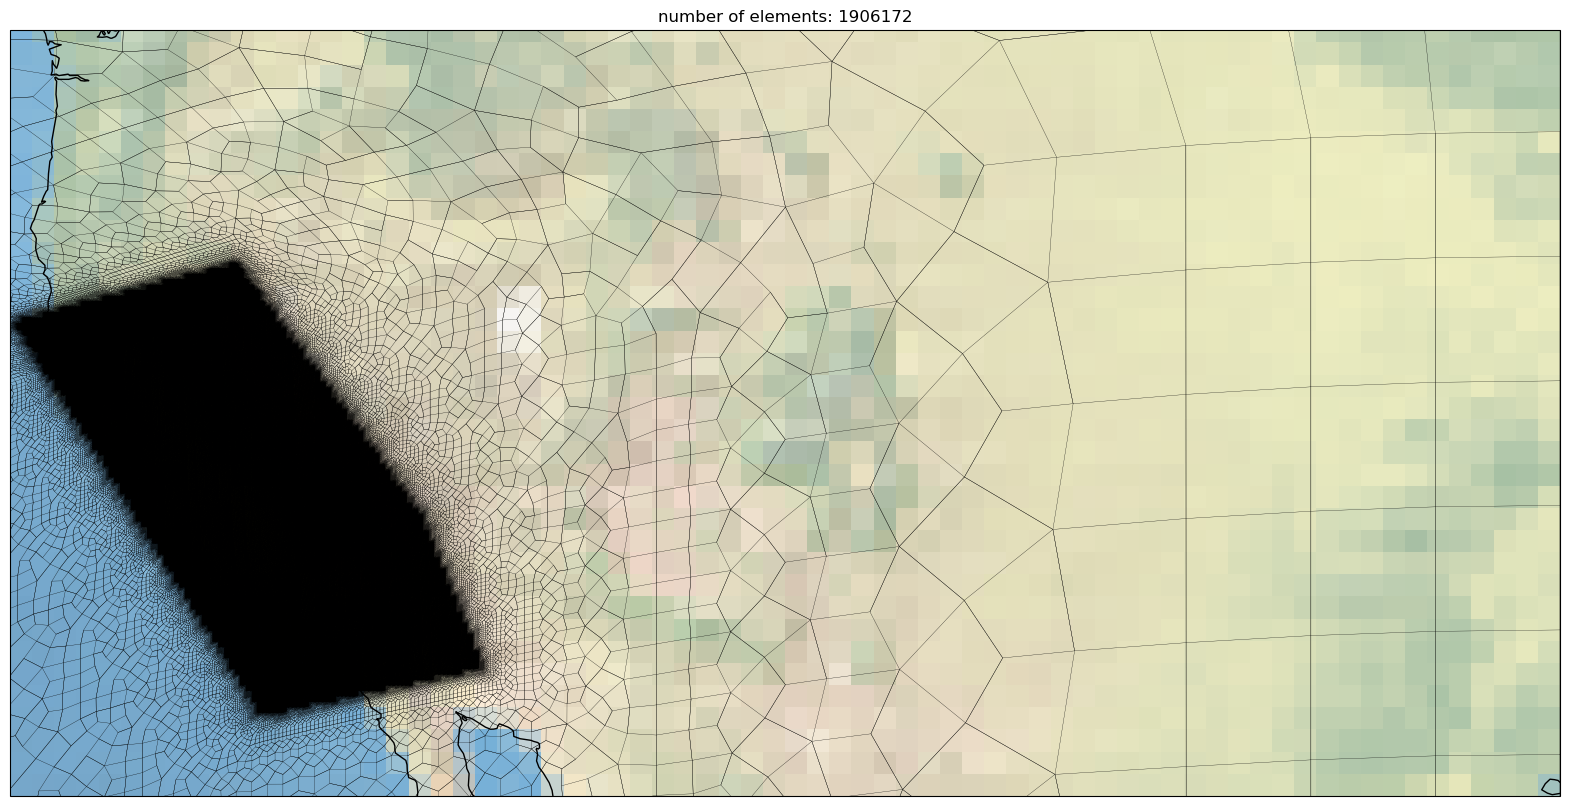

In [ ]:
import os
from os.path import splitext, basename
from matplotlib import pyplot as plt, patches
from cartopy import crs
from xarray import open_dataset
from e3smplot.mpl.plot_exodus import plot_exodus

meshes = [
    '/tscratch/smturbe/e3sm_grids/CA_ne32_x256/CAne32_x512_v1.g'
    # add other meshes here for comparison
]
refined_mesh = meshes[0]
print(refined_mesh)
os.makedirs('graphics', exist_ok=True)
# for refined_mesh in meshes:
ds2 = open_dataset(refined_mesh, engine="netcdf4")
figure = plt.figure(figsize=(20, 10))
ax = figure.add_subplot(111, projection=crs.PlateCarree())
ax.stock_img()
ax.coastlines()
ax.set_global()
extent = (-125, -90, 30, 46)
ax.set_extent(extent)
ax.set_title(f'number of elements: {ds2.dims["num_elem"]}')
pl = plot_exodus(ds2, ax=ax, verbose=True, linewidth=0.2)
figure.savefig(f'graphics/{basename(splitext(refined_mesh)[0])}.pdf', bbox_inches='tight')
figure.savefig(f'graphics/{basename(splitext(refined_mesh)[0])}.png', bbox_inches='tight')